In [13]:
import numpy as np
import pandas as pd

1. What is the average, median, and mode of PurchaseAmount?

In [2]:
df=pd.read_csv("customer_behavior.csv")
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [3]:
mean_purch=df["PurchaseAmount"].mean()
median_purch=df["PurchaseAmount"].median()
mode_purch=df["PurchaseAmount"].mode()[0]

In [4]:
print("Mean: ",mean_purch)
print("Median: ",median_purch)
print("Mode: ",mode_purch)

Mean:  1003.9506701030928
Median:  998.0799999999999
Mode:  0.0


2. Are there any outliers in the PurchaseAmount data?

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='PurchaseAmount'>

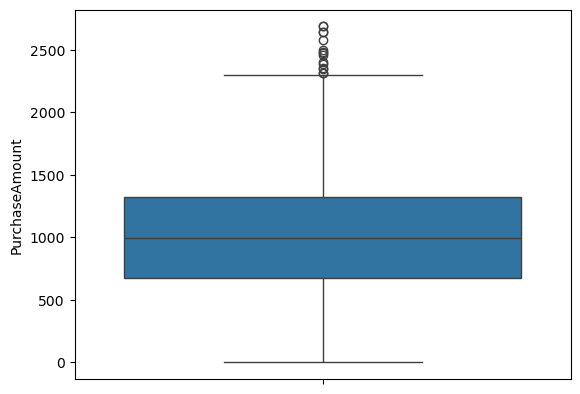

In [6]:
sns.boxplot(df["PurchaseAmount"])

In [7]:
q1=df["PurchaseAmount"].quantile(0.25)
q3=df["PurchaseAmount"].quantile(0.75)
iqr=q3-q1

In [8]:
outliers=df[(df["PurchaseAmount"]<q1-1.5*iqr)|(df["PurchaseAmount"]>q3+1.5*iqr)]
print("No. of outliers:",len(outliers))

No. of outliers: 15


3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

In [9]:
print("Skewness:",df["PurchaseAmount"].skew())
print("Kurtosis:",df["PurchaseAmount"].kurt())

Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705


4. Is there a significant difference in spending between male and female
customers?

In [10]:
from scipy.stats import ttest_ind
male=df[df["Gender"]=="Male"]["PurchaseAmount"]
female=df[df["Gender"]=="Female"]["PurchaseAmount"]
print("Male avg: ",male.mean())
print("Female avg: ",female.mean())

Male avg:  1019.1766093880971
Female avg:  987.8720464135021


In [11]:
print(ttest_ind(male,female))

TtestResult(statistic=nan, pvalue=nan, df=nan)


There is a significant difference between male and female spending.

#5. Is there a relationship between ProductCategory and customer churn?

In [14]:
from scipy.stats import chi2_contingency
table=pd.crosstab(df["ProductCategory"],df["Churn"])
print(chi2_contingency(table))

Chi2ContingencyResult(statistic=0.3960436652673918, pvalue=0.8203519424988512, dof=2, expected_freq=array([[776.9212952 , 549.0787048 ],
       [847.23091468, 598.76908532],
       [854.84779012, 604.15220988]]))


6. Does PurchaseAmount vary significantly across different regions?

In [ ]:
from scipy.stats import f_oneway
groups = [
    group['PurchaseAmount'].dropna()
    for name, group in df.groupby('Region')
]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

7. Which email campaign (A or B) performed better in terms of average
PurchaseAmount?

In [16]:
print(df.groupby('CampaignGroup')['PurchaseAmount'].mean())

CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64


Campaign A performed better based on average PurchaseAmount.

#8. Can we assume PurchaseAmount follows a normal distribution?

In [20]:
from scipy.stats import shapiro
data=df['PurchaseAmount'].dropna()
stat,p=shapiro(data)
print("P-value:", p)

P-value: 5.744127799493938e-12


The p-value is very small (< 0.05), so strictly speaking, we reject the normality assumption.

9. What insights can we gain by applying the Central Limit Theorem?

The Central Limit Theorem says that when we take many random samples, the sample means tend to follow a normal distribution, even if the original data is not perfectly normal.

Here, the dataset has 4,850 valid PurchaseAmount values, so the sample mean can be considered reasonably stable.

10.What is the 95% confidence interval for the average PurchaseAmount?

In [18]:
from scipy.stats import t
data=df['PurchaseAmount'].dropna()
mean=data.mean()
sem=data.sem()
lower,upper=t.interval(
    0.95,
    len(data)-1,
    loc=mean,
    scale=sem
)
print("95% Confidence Interval:", lower, upper)

95% Confidence Interval: 990.3789594609216 1017.522380745264
